In [33]:
from multi_dim_engine import Tensor
from optimizer import Adam
import numpy as np
import matplotlib.pyplot as plt

In [34]:

def cross_entropy_loss(index_vector,scores) :
    # we get the probabilities matrix
    probabilities = softmax(scores)

    #set up for the advanced indexing
    rows = np.arange(probabilities.data.shape[0])
    true_prob = Tensor(probabilities.data[rows, index_vector])

    #calculating the losses 
    losses = Tensor(-np.log(true_prob.data))
    N = true_prob.data.shape[0]
    
    full_loss = Tensor(losses.data.mean() ,(scores,))

    def _backward() :
        num_classes = probabilities.data.shape[1]
        Y = np.eye(num_classes)[index_vector]
        scores.grad = (probabilities.data - Y)/N
        
    full_loss._backward = _backward
        
    return full_loss

def softmax(scores) :
    shifted_scores = scores.data - np.max(scores.data , axis = -1 , keepdims=True)
    expon = np.exp(shifted_scores)
    prob = expon / np.sum(expon, axis = -1, keepdims=True)
    prob = np.clip(prob, 1e-12 , 1.0 - 1e-12)
    return Tensor(prob)
    

class Layer :

    def __init__(self, n_inputs , n_neurons) :
        self.w = Tensor(np.random.rand(n_neurons,n_inputs))
        self.b = Tensor(np.random.rand(n_neurons))

    def __call__(self,x) :
        output = x @ self.w.T() + self.b
        return output

    def parameters(self) :
        return [self.w , self.b]
    

    
class MLP : 

    def __init__(self, n_inputs,n_outputs) :
        size = [n_inputs] + n_outputs 
        self.layers = [Layer(size[i], size[i+1]) for i in range(len(size)-1)]

    def __call__(self,x) :
        for layer in self.layers[:-1] : 
            x = layer(x).relu()
        scores = self.layers[-1](x)
        return scores

    def parameters(self) :
        params = []
        for layer in self.layers :
            params.extend(layer.parameters())
        return params

In [35]:
model = MLP(784,[128,64,10])

In [ ]:
import torch
from torchvision import datasets

train_dataset = datasets.MNIST(root='./data', train=True, download=True)

X_train = train_dataset.data.numpy().reshape(-1, 784).astype('float32') / 255.0
y_train = train_dataset.targets.numpy()

print(X_train.shape)

(60000, 784)


In [ ]:
batch_size = 64
num_samples = X_train.shape[0]
optimizer = Adam(model.parameters(), 0.005)  

for epoch in range(20):
    indices = np.arange(num_samples)
    np.random.shuffle(indices)

    running_loss = 0.0
    num_batches = num_samples // batch_size

    for i in range(num_batches):
        idx = indices[i * batch_size : (i + 1) * batch_size]
        x_batch = Tensor(X_train[idx])
        y_batch = y_train[idx]

        scores = model(x_batch)
        loss = cross_entropy_loss(y_batch, scores)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.data

    print(
        f"Epoch {epoch + 1} | Average Loss = {running_loss / num_batches:.4f}"
    )

Epoch 1 | Average Loss = 8.6573
Epoch 2 | Average Loss = 1.9973
Epoch 3 | Average Loss = 0.3973
Epoch 4 | Average Loss = 0.2663
Epoch 5 | Average Loss = 0.2120
Epoch 6 | Average Loss = 0.1830
Epoch 7 | Average Loss = 0.1569
Epoch 8 | Average Loss = 0.1304
Epoch 9 | Average Loss = 0.1154
Epoch 10 | Average Loss = 0.1024
Epoch 11 | Average Loss = 0.0883
Epoch 12 | Average Loss = 0.0819
Epoch 13 | Average Loss = 0.0692
Epoch 14 | Average Loss = 0.0667
Epoch 15 | Average Loss = 0.0624
Epoch 16 | Average Loss = 0.0593
Epoch 17 | Average Loss = 0.0550
Epoch 18 | Average Loss = 0.0521
Epoch 19 | Average Loss = 0.0498
Epoch 20 | Average Loss = 0.0457


In [ ]:

test_dataset = datasets.MNIST(root="./data", train=False, download=True)

X_test = test_dataset.data.numpy().reshape(-1, 784).astype("float32") / 255.0
y_test = test_dataset.targets.numpy()



In [ ]:
test_scores = model(Tensor(X_train))
test_preds = np.argmax(test_scores.data, axis=1)

accuracy = np.mean(test_preds == y_train) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.11%


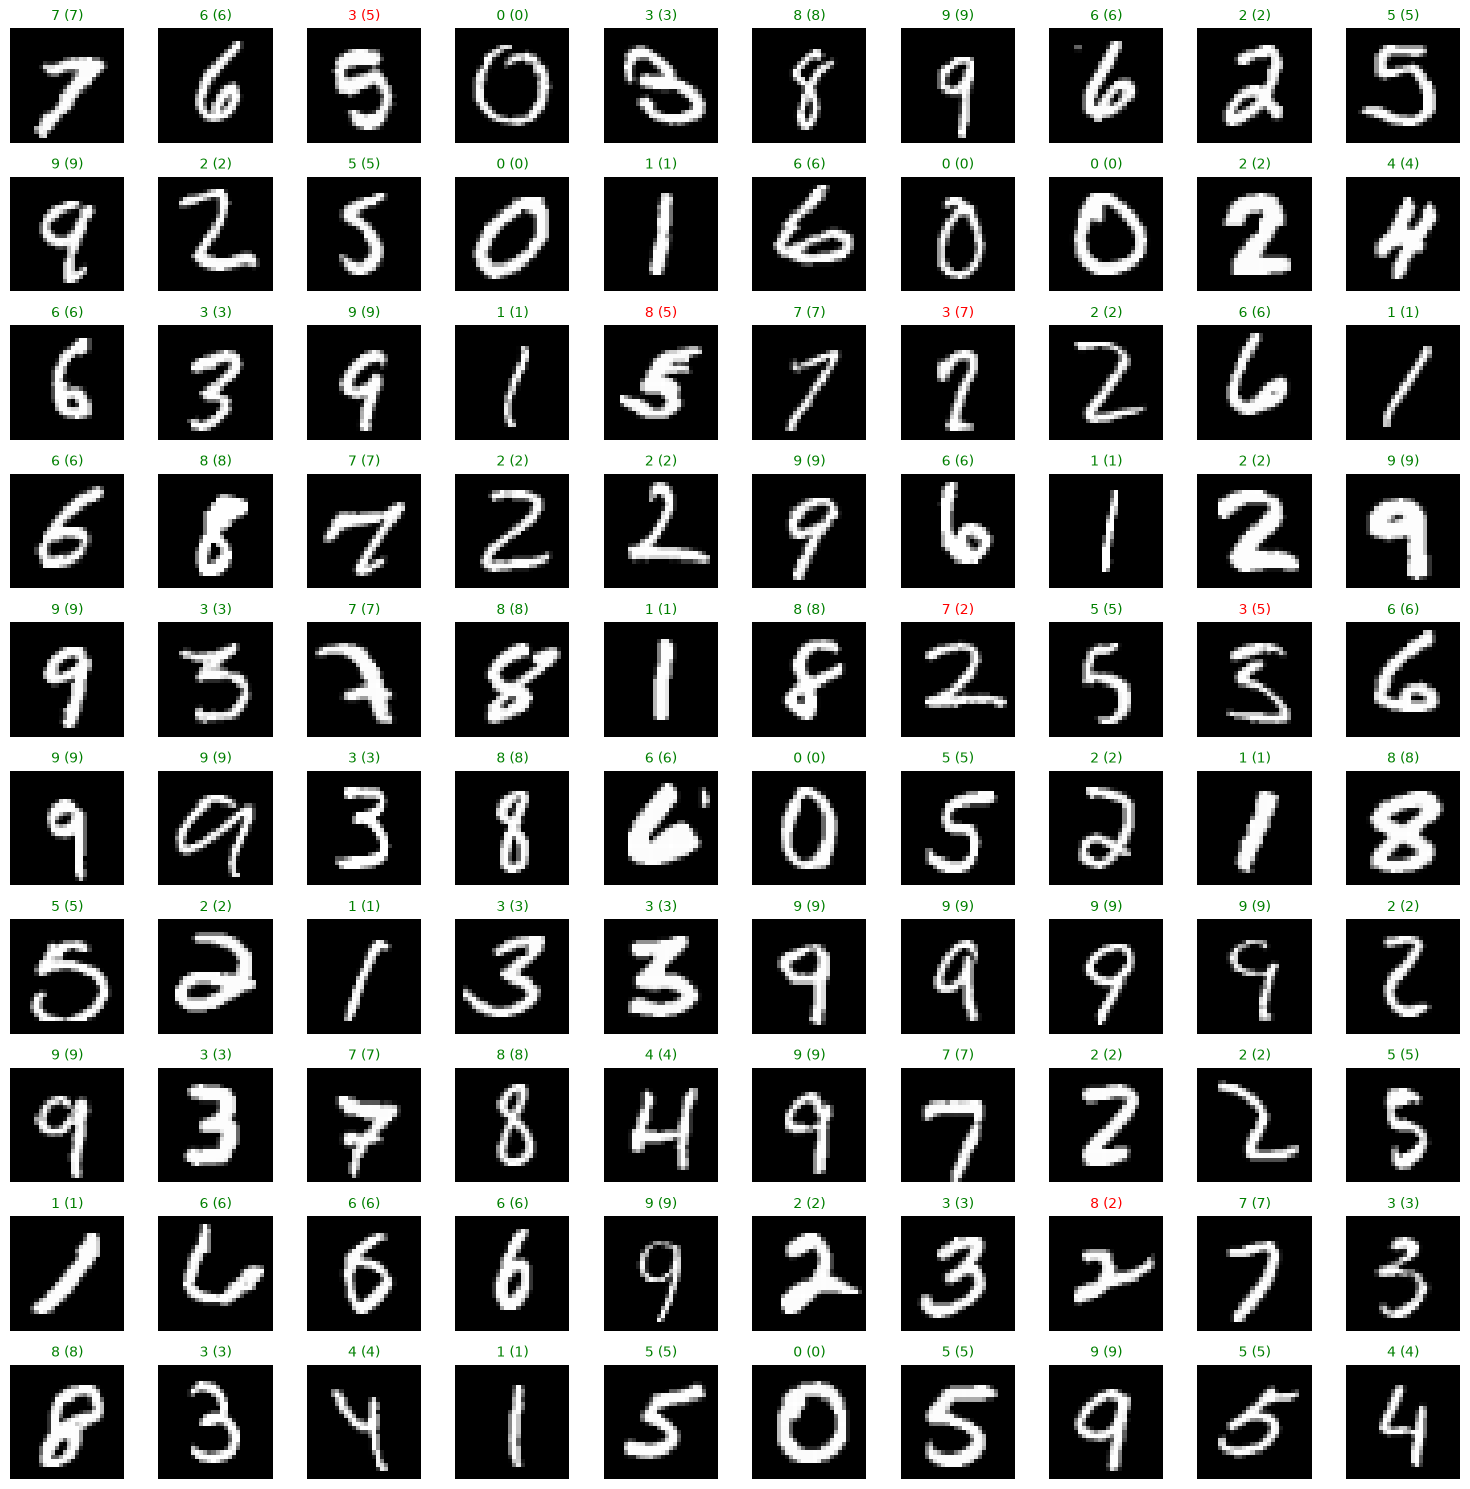

In [ ]:

batch_size = 100
indices = np.random.choice(len(X_test), size=batch_size, replace=False)

x_sample = Tensor(X_test[indices])
y_true = y_test[indices]

scores = model(x_sample)
predictions = np.argmax(scores.data, axis=1)

fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    image = X_test[indices[i]].reshape(28, 28)
    ax.imshow(image, cmap="gray")

    pred = predictions[i]
    true = y_true[i]

    color = "green" if pred == true else "red"
    ax.set_title(f"{pred} ({true})", color=color, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()